In [ ]:
# =====================================
# STUDENT PERFORMANCE ANALYSIS PROJECT
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("Student_Performance.csv")

print(df.head())
print(df.info())

# ==============================
# DATA CLEANING
# ==============================

print(df.isnull().sum())


   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------              

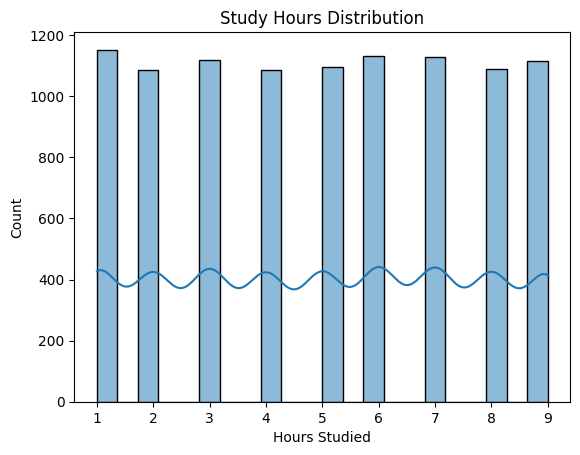

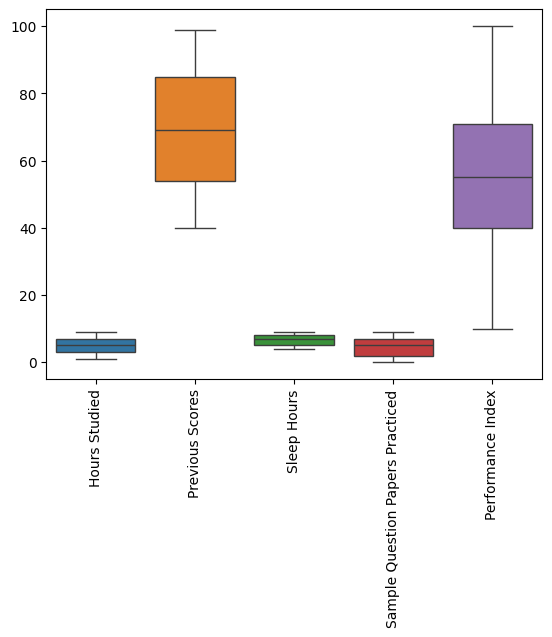

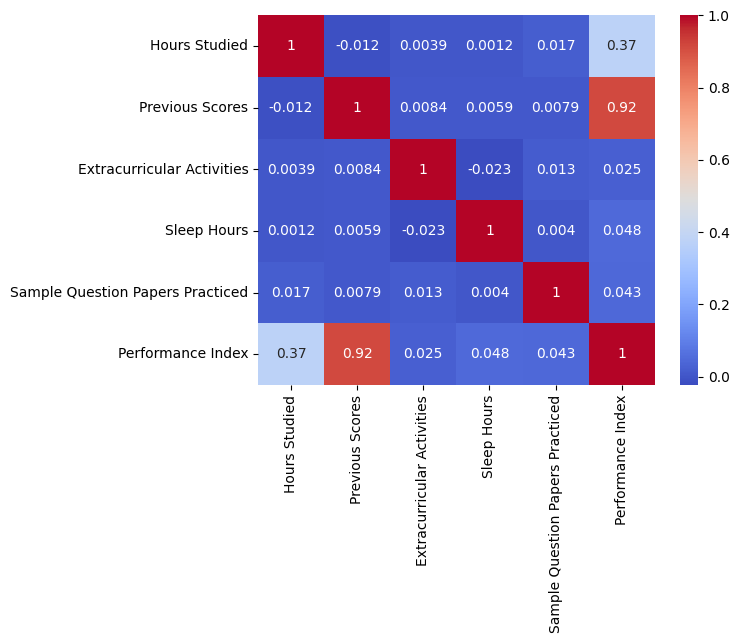

In [ ]:
# ==============================
# EDA
# ==============================

# Distribution
sns.histplot(df['Hours Studied'], kde=True)
plt.title("Study Hours Distribution")
plt.show()

# Boxplot
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Correlation
# Convert 'Extracurricular Activities' to numerical values for correlation
df_encoded = df.copy()
df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# ==============================
# MODEL BUILDING
# ==============================

from sklearn.model_selection import train_test_split

# Encode 'Extracurricular Activities' before splitting
X = df.drop(columns=['Performance Index']).copy()
X['Extracurricular Activities'] = X['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train, X_test, y_train, y_test)

      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
9254              5               49                           0            7   
1561              2               48                           1            7   
1670              2               81                           0            7   
6087              2               46                           0            6   
6669              8               47                           0            9   
...             ...              ...                         ...          ...   
5734              8               50                           1            6   
5191              4               68                           0            9   
5390              9               48                           0            7   
860               1               47                           0            9   
7270              2               46                           0            6   

      Sample Question Paper

In [ ]:
# ==============================
# MODELS
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R2:", r2_score(y_test, pred))

Linear R2: 0.9889832909573145
Decision Tree R2: 0.9759830628371906
Random Forest R2: 0.9860961329827461


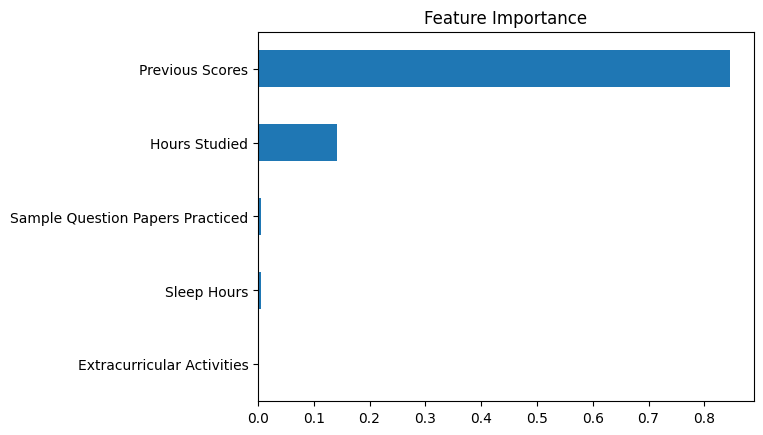

In [ ]:
# ==============================
# FEATURE IMPORTANCE (BEST PART)
# ==============================

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importance = rf.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


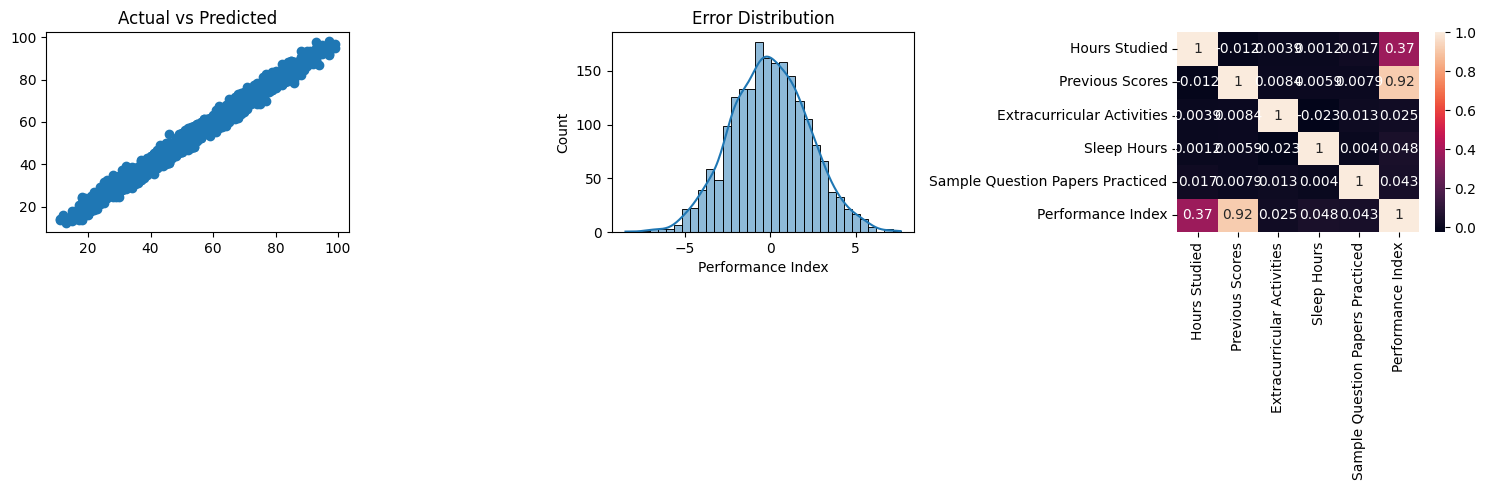

In [ ]:
# ==============================
# FINAL DASHBOARD
# ==============================

pred = rf.predict(X_test)

plt.figure(figsize=(15,5))

# Actual vs Predicted
plt.subplot(1,3,1)
plt.scatter(y_test, pred)
plt.title("Actual vs Predicted")

# Error Distribution
plt.subplot(1,3,2)
sns.histplot(y_test - pred, kde=True)
plt.title("Error Distribution")

# Correlation
plt.subplot(1,3,3)
sns.heatmap(df_encoded.corr(), annot=True)

plt.tight_layout()
plt.show()